In [ ]:
!pip install jinja2
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
import matplotlib.pyplot as plt
import time
import pandas as pd

STUDENT_SEED = 421944 
IMAGE_SIZE = (128, 128)
IMAGE_SIZE_ALTERNATIVE = (244, 244)
BATCH_SIZE = 32
NUM_CLASSES = 19

np.random.seed(STUDENT_SEED)
tf.random.set_seed(STUDENT_SEED)

# GPU Check since im running this locally on my NVIDIA 4060 8GB
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [27]:
model_performance_tracker = {}

## Helper Functions

These are functions used throughout the code

### Plot

In [2]:
def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curves
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy curves
    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_model_comparison(histories_dict, title='Model Architecture Comparison'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for model_name, history in histories_dict.items():

        p = ax1.plot(history.history['loss'], label=f'{model_name} (Train Loss)', linestyle='-')
        color = p[0].get_color() 
        ax1.plot(history.history['val_loss'], label=f'{model_name} (Val Loss)', linestyle='--', color=color)
        
        ax2.plot(history.history['accuracy'], label=f'{model_name} (Train Acc)', linestyle='-', color=color)
        ax2.plot(history.history['val_accuracy'], label=f'{model_name} (Val Acc)', linestyle='--', color=color)

    ax1.set_title('Loss Comparison')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.set_title('Accuracy Comparison')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

## Data Preparation

- `image_dataset_from_directory` Loads the images in batches from disk rather than everything into memory at once

### References
- [TensorFlow Documentation](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory#:%7E:text=or%204%20channels.-,batch_size,-Size%20of%20the)
- [Stackoverflow](https://stackoverflow.com/questions/66036271/splitting-a-tensorflow-dataset-into-training-test-and-validation-sets-from-ker)

In [72]:
train_ds = keras.utils.image_dataset_from_directory(
    "./food",
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="training"
)

print(train_ds)

remaining_ds = keras.utils.image_dataset_from_directory(
    "./food",
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="validation"
)

print(remaining_ds)

remaining_batches = tf.data.experimental.cardinality(remaining_ds).numpy()
val_batches = int(remaining_batches * 0.33)
test_batches = remaining_batches - val_batches

val_ds = remaining_ds.take(val_batches)
test_ds = remaining_ds.skip(val_batches)

Found 19000 files belonging to 19 classes.
Using 13300 files for training.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Found 19000 files belonging to 19 classes.
Using 5700 files for validation.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [73]:
class_names = train_ds.class_names
print(class_names)

num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

['carrot_cake', 'cheesecake', 'chicken_wings', 'chocolate_cake', 'donuts', 'fish_and_chips', 'french_fries', 'fried_rice', 'garlic_bread', 'hamburger', 'hot_dog', 'nachos', 'onion_rings', 'pancakes', 'pizza', 'red_velvet_cake', 'spaghetti_bolognese', 'steak', 'waffles']
Number of classes: 19


## Normalisation

Since every pixel in the image is stored as a number from 0 to 255 where like 0 is compelely dark, then 255 is full brightness, white in greyscale or full RGB. So normalising the data will map it between 0.0 and 1.0.

Doing this doesnt actually change how the image works, but it does help for weight initialisations. So later on when training starts, the weights are initialised as smaller random numbers, but if the inputs are like 0-255, the initial dot products are enourmous, which isnt good. It also works best when using the Gradient Descent optimiser ADAM

In [5]:
normalisation_layer = keras.layers.Rescaling(1./255)

## Class Imbalance

So this occurs when some categories have more images than others. For example, if Pizza has 2000 images but sushi has 200, the model will acheive 90% accuracy by just predicing pizza, making it useless for other classes.

### Checking for class distribution

First we can check for the distribution for each image type, since the folders are named after the food they contain, it makes it easier to plot them on a bar chart, the results show that for each food type, there is 1000 images, so there is equal class distribution.

```
=> carrot_cake: 1000
=> cheesecake: 1000
=> chicken_wings: 1000
=> chocolate_cake: 1000
=> donuts: 1000
=> fish_and_chips: 1000
=> french_fries: 1000
=> fried_rice: 1000
=> garlic_bread: 1000
=> hamburger: 1000
=> hot_dog: 1000
=> nachos: 1000
=> onion_rings: 1000
=> pancakes: 1000
=> pizza: 1000
=> red_velvet_cake: 1000
=> spaghetti_bolognese: 1000
=> steak: 1000
=> waffles: 1000
```

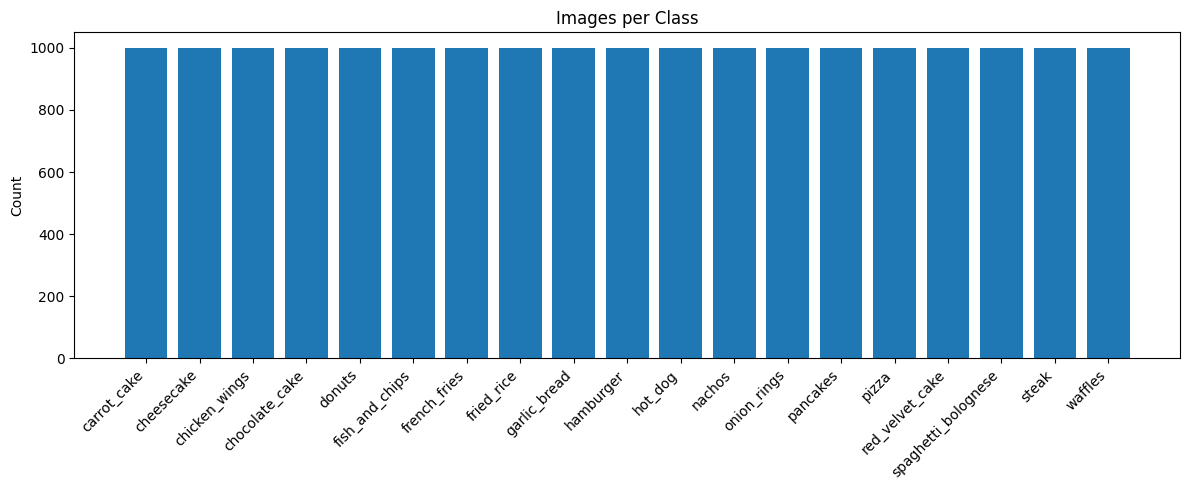

=> carrot_cake: 1000
=> cheesecake: 1000
=> chicken_wings: 1000
=> chocolate_cake: 1000
=> donuts: 1000
=> fish_and_chips: 1000
=> french_fries: 1000
=> fried_rice: 1000
=> garlic_bread: 1000
=> hamburger: 1000
=> hot_dog: 1000
=> nachos: 1000
=> onion_rings: 1000
=> pancakes: 1000
=> pizza: 1000
=> red_velvet_cake: 1000
=> spaghetti_bolognese: 1000
=> steak: 1000
=> waffles: 1000


In [6]:
import os
import matplotlib.pyplot as plt

data_dir = './food/'
class_counts = {}

for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        class_counts[class_name] = count

# Plot it
plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha='right')
plt.title('Images per Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

for name, count in class_counts.items():
    print(f"=> {name}: {count}")

### Imbalanced Classes

Although the images provided in the food dataset is perfectly balanced at 1000 images, this isnt always the case. Many real world datasets would have variation in the number of images, which will create an imbalance.

In this way, the model learns to favour majority classes, where teh accuracy looks high but minority class performance is terrible. Introducing class weights will allow each class to be treated fairly.

In [7]:
import numpy as np

total_images = sum(class_counts.values())
num_classes = len(class_counts)

class_weights = {}
for i, class_name in enumerate(sorted(class_counts.keys())):
    count = class_counts[class_name]
    # Classes with fewer images get higher weight
    weight = total_images / (num_classes * count)
    class_weights[i] = weight

print(class_weights)

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0, 10: 1.0, 11: 1.0, 12: 1.0, 13: 1.0, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.0}


## Exploratory Data Analysis

Number of classes: 19
Number of images: 19000
Image size: 128×128
Colour mode: RGB (3 channels)
Train: 13312 images
Val:   1888 images
Test:  3840 images


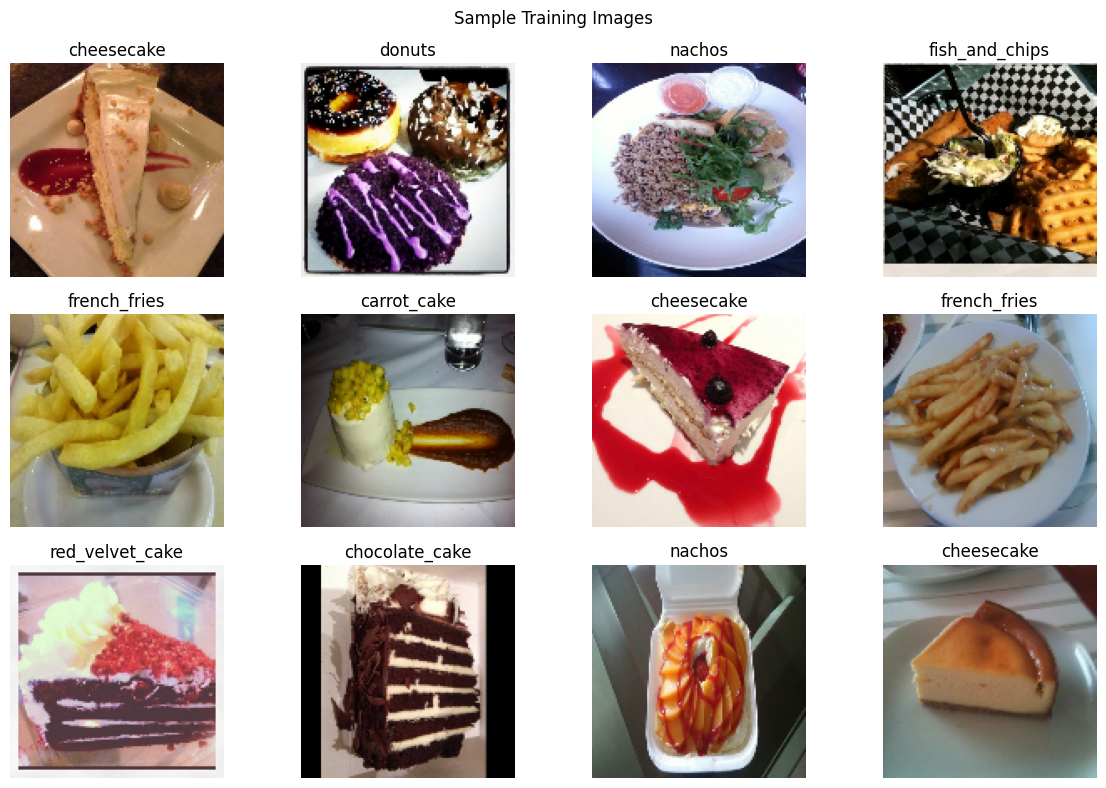

In [74]:
print(f"Number of classes: {len(class_counts)}")
print(f"Number of images: {total_images}")

for images, labels in train_ds.take(1):
    h, w, c = images[0].shape
    print(f"Image size: {h}×{w}")
    print(f"Colour mode: {'RGB' if c == 3 else 'Greyscale'} ({c} channel{'s' if c > 1 else ''})")

train_count = tf.data.experimental.cardinality(train_ds).numpy() * BATCH_SIZE
val_count   = tf.data.experimental.cardinality(val_ds).numpy()   * BATCH_SIZE
test_count  = tf.data.experimental.cardinality(test_ds).numpy()  * BATCH_SIZE

print(f"Train: {train_count} images")
print(f"Val:   {val_count} images")
print(f"Test:  {test_count} images")


plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1): 
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

## CNN From Scratch

### Baseline Model

In [75]:
def build_baseline_cnn(input_shape, num_classes, target_size=(244, 244)):
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Resizing(target_size[0], target_size[1]),
        layers.Rescaling(1./255),

        # BLOCK 1
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # BLOCK 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CLASSIFIER
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])

baseline_model = build_baseline_cnn(
    input_shape=(128, 128, 3), 
    num_classes=NUM_CLASSES, 
    target_size=IMAGE_SIZE
)
baseline_model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_22 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_110 (Conv2D)             │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_92 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_111 (Conv2D)             │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_93 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 19)             │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,410,579 (32.08 MB)

 Trainable params: 8,410,579 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

#### Compiling the model

- `loss='sparse_categorical_crossentropy',` labels are ints like 0,1,2,3 etc

In [76]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Training the model

So based on the data results produced and graphed below, we will notice that over the course of the 20 epochs that the training loss decreases while the validation loss increases. As well the training accurracy increases and the val stops around 2.2 accuracy.

This is a clear sign of overfitting, as the training loss decreases while validation increases in loss. The model is failing to learn general patterns, but instead memorising the training images!

To combat this, will add a dropout to the neural network, and augment the data such as rotating images etc

In [77]:
start_time = time.time()

EPOCHS=20

baseline_model_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

end_time = time.time()
total_time = end_time - start_time

model_performance_tracker["Baseline CNN"] = {
    "Total Time (s)": round(total_time, 2),
    "Time/Epoch (s)": round(total_time / EPOCHS, 2),
    "Epochs": EPOCHS,
    "Image Size:" IMAGE_SIZE,
    "Final Train Acc": round(baseline_model_history.history['accuracy'][-1], 4),
    "Final Val Acc": round(baseline_model_history.history['val_accuracy'][-1], 4),
    "Final Train Loss": round(baseline_model_history.history['loss'][-1], 4), 
    "Final Val Loss": round(baseline_model_history.history['val_loss'][-1], 4)  
}

Epoch 1/20


I0000 00:00:1778000149.775116   42497 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1241872__.32


415/416 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1073 - loss: 2.9429

I0000 00:00:1778000158.588728   42494 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1241872__.32


416/416 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.1498 - loss: 2.7234 - val_accuracy: 0.2135 - val_loss: 2.5370
Epoch 2/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.2758 - loss: 2.3323 - val_accuracy: 0.2489 - val_loss: 2.4351
Epoch 3/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.4156 - loss: 1.8849 - val_accuracy: 0.2675 - val_loss: 2.4344
Epoch 4/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.6043 - loss: 1.2880 - val_accuracy: 0.2632 - val_loss: 2.9554
Epoch 5/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7851 - loss: 0.7137 - val_accuracy: 0.2479 - val_loss: 3.7132
Epoch 6/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8969 - loss: 0.3589 - val_accuracy: 0.2447 - val_loss: 4.7665
Epoch 7/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9481 - loss: 0.1857 - val_accuracy: 0.2309 - val_loss: 5.4778
Epoch 8/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9687 - loss: 0.1223 - val_accuracy: 0.23

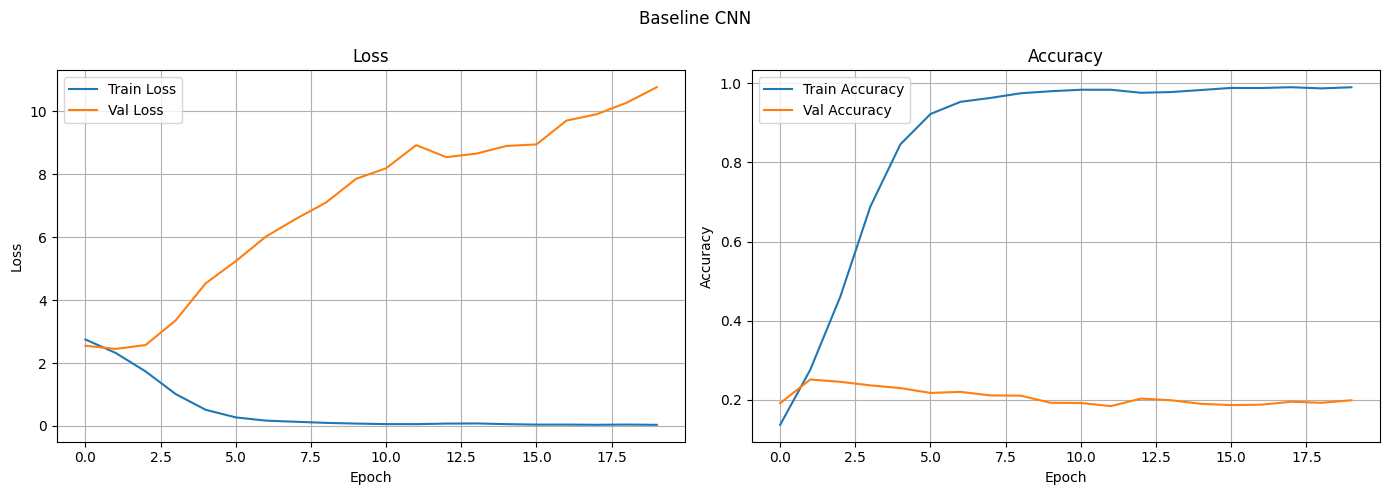

In [12]:
plot_history(baseline_model_history, title='Baseline CNN')

#### Improving the Model

So as mentioned above, the model is struggling to generalise on unseen data from our validation set, instead is memorising training patterns and images. To help combat this, I will be increasing the block count from 2 - 3, adding dropout at 0.5 and increasing the convolution layers to 2 before downsampling, to hopefully allow to to extract more complex patterns.

In [ ]:
# Just add this list and a loop at the top
for current_size in [IMAGE_SIZE, IMAGE_SIZE_ALTERNATIVE]:
    
    # 1. Pass current_size to your model build
    # Note: Added layers.Resizing here to "force" the size as requested
    deeper_model = keras.Sequential([
        layers.Input(shape=(128, 128, 3)),
        layers.Resizing(current_size[0], current_size[1]),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])

    deeper_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start_time = time.time()
    EPOCHS = 20
    deeper_model_history = deeper_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        class_weight=class_weights
    )

    end_time = time.time()
    total_time = end_time - start_time

    # Use the current_size in the dictionary key to keep them separate
    tracker_key = f"Model V2 ({current_size[0]}x{current_size[1]})"
    
    model_performance_tracker[tracker_key] = {
        "Image Size": current_size, # This stores the size used
        "Total Time (s)": round(total_time, 2),
        "Time/Epoch (s)": round(total_time / EPOCHS, 2),
        "Epochs": EPOCHS,
        "Final Train Acc": round(deeper_model_history.history['accuracy'][-1], 4),
        "Final Val Acc": round(deeper_model_history.history['val_accuracy'][-1], 4),
        "Final Train Loss": round(deeper_model_history.history['loss'][-1], 4), 
        "Final Val Loss": round(deeper_model_history.history['val_loss'][-1], 4)  
    }

/home/michael/miniconda3/envs/ml_assignment/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,680,755 (33.11 MB)

 Trainable params: 8,680,755 (33.11 MB)

...

Epoch 1/20


I0000 00:00:1777982313.711638   42504 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_43432__.43


414/416 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0501 - loss: 2.9470

I0000 00:00:1777982336.647899   42502 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_43432__.43


416/416 ━━━━━━━━━━━━━━━━━━━━ 34s 58ms/step - accuracy: 0.0496 - loss: 2.9454 - val_accuracy: 0.0551 - val_loss: 2.9448
Epoch 2/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.0507 - loss: 2.9447 - val_accuracy: 0.0572 - val_loss: 2.9449
Epoch 3/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.0530 - loss: 2.9448 - val_accuracy: 0.0561 - val_loss: 2.9449
Epoch 4/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.0526 - loss: 2.9447 - val_accuracy: 0.0535 - val_loss: 2.9452
Epoch 5/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.0527 - loss: 2.9446 - val_accuracy: 0.0561 - val_loss: 2.9452
Epoch 6/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.0528 - loss: 2.9446 - val_accuracy: 0.0551 - val_loss: 2.9451
Epoch 7/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.0528 - loss: 2.9446 - val_accuracy: 0.0572 - val_loss: 2.9452
Epoch 8/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.0516 - loss: 2.9446 - val_accurac

#### Combatting Underfitting

This is a case now where the model is underfitting on the data, rather than overfitting. Based on the chart data the model is struggling with around 5% accuracy for validation and the model cant find any more patterns to improve its accuracy.

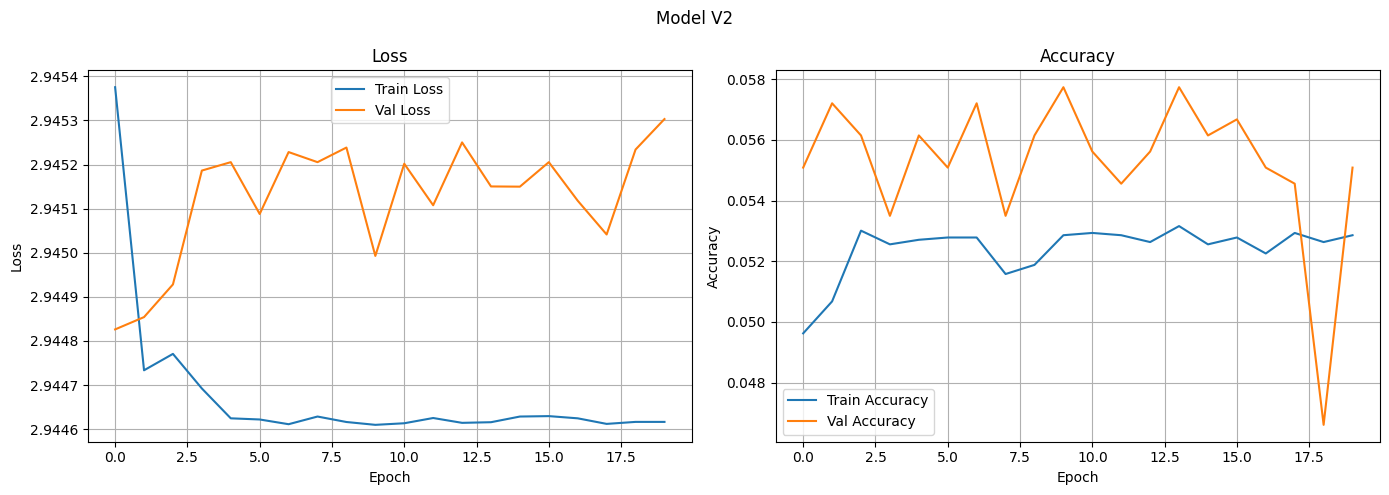

In [15]:
plot_history(deeper_model_history, title='Model V2')

#### Batch stuff (Overfitting)

The model is improving far better than before, with the training loss steadily decreasing smoothly with every epoch, showing it is finding and learning different patterns from our data. As well the train accuracy is increasing steadily with it. The validation set is performing better than before as the accuracy is increasing along with the training acurracy albeit stagnant.

In [ ]:
def build_cnn_deeper_net(input_shape, num_classes):
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(), 
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(), 
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])

cnn_deeper_net_model = build_cnn_deeper_net(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)
cnn_deeper_net_model.summary()

cnn_deeper_net_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
EPOCHS=40

cnn_deeper_net_model_history = cnn_deeper_net_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

end_time = time.time()
total_time = end_time - start_time

model_performance_tracker["Model V3"] = {
    "Total Time (s)": round(total_time, 2),
    "Time/Epoch (s)": round(total_time / EPOCHS, 2),
    "Epochs": EPOCHS,
    "Final Train Acc": round(cnn_deeper_net_model_history.history['accuracy'][-1], 4),
    "Final Val Acc": round(cnn_deeper_net_model_history.history['val_accuracy'][-1], 4),
    "Final Train Loss": round(cnn_deeper_net_model_history.history['loss'][-1], 4), 
    "Final Val Loss": round(cnn_deeper_net_model_history.history['val_loss'][-1], 4)  
}

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,299 (161.32 KB)

 Trainable params: 41,107 (160.57 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20


I0000 00:00:1777982619.471254   42503 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_84849__.43
I0000 00:00:1777982619.666213   42503 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


414/416 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0741 - loss: 2.9493

I0000 00:00:1777982629.550242   42503 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_84849__.43


416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.0925 - loss: 2.8971 - val_accuracy: 0.1038 - val_loss: 2.8883
Epoch 2/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.1380 - loss: 2.7696 - val_accuracy: 0.1859 - val_loss: 2.7038
Epoch 3/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.1669 - loss: 2.6875 - val_accuracy: 0.2188 - val_loss: 2.6153
Epoch 4/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.1902 - loss: 2.6147 - val_accuracy: 0.2283 - val_loss: 2.5444
Epoch 5/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.2011 - loss: 2.5639 - val_accuracy: 0.2405 - val_loss: 2.5090
Epoch 6/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.2170 - loss: 2.5141 - val_accuracy: 0.2484 - val_loss: 2.4647
Epoch 7/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.2315 - loss: 2.4775 - val_accuracy: 0.2521 - val_loss: 2.4291
Epoch 8/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.2461 - loss: 2.4414 - val_accuracy: 0.26

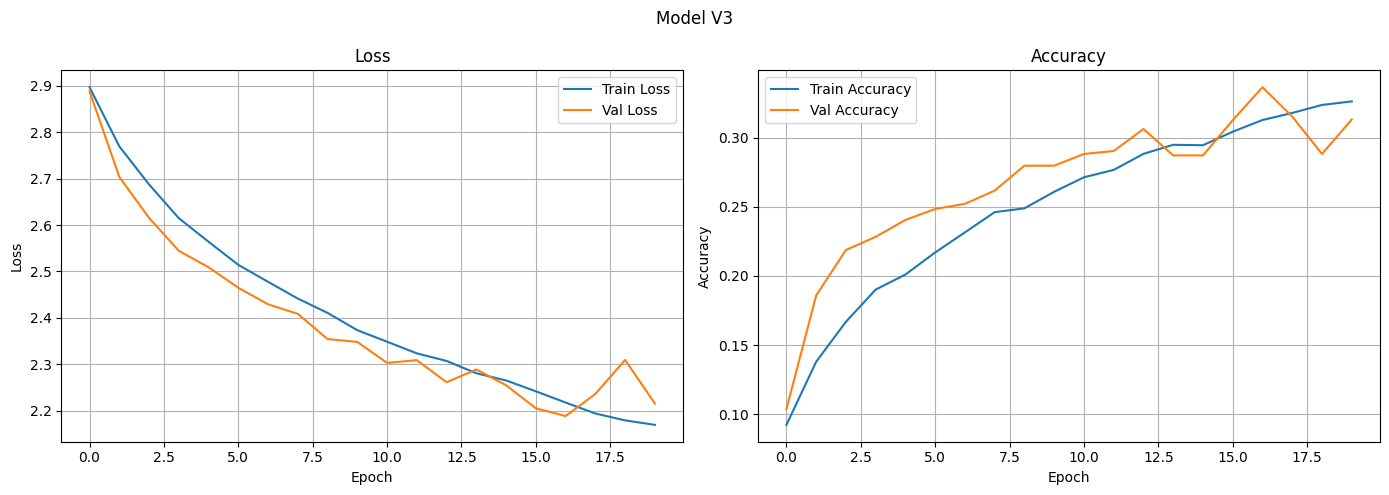

In [17]:
plot_history(cnn_deeper_net_model_history, title='Model V3')

## Good stable

Both training accuracy and validatio accuracy increasing together.

Added 

```
layers.RandomFlip('horizontal'),
layers.RandomRotation(0.1),
layers.RandomZoom(0.1),
```

and made epochs 40

"Adding rotation and zoom augmentation improved the stability of the training loss but introduced significant volatility in the validation metrics. The final validation accuracy of 38% suggests that while the model is learning general features, it remains sensitive to extreme image transformations."

In [ ]:
def build_food_cnn_stable(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(), # Keeps the math stable
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(), # Reduces parameter explosion
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

food_cnn_stable_model = build_food_cnn_stable(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)
food_cnn_stable_model.summary()

food_cnn_stable_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
EPOCHS=60

food_cnn_stable_model_history = food_cnn_stable_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

end_time = time.time()
total_time = end_time - start_time

model_performance_tracker["Model V4"] = {
    "Total Time (s)": round(total_time, 2),
    "Time/Epoch (s)": round(total_time / EPOCHS, 2),
    "Epochs": EPOCHS,
    "Final Train Acc": round(food_cnn_stable_model_history.history['accuracy'][-1], 4),
    "Final Val Acc": round(food_cnn_stable_model_history.history['val_accuracy'][-1], 4),
    "Final Train Loss": round(food_cnn_stable_model_history.history['loss'][-1], 4), 
    "Final Val Loss": round(food_cnn_stable_model_history.history['val_loss'][-1], 4)  
}

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,299 (161.32 KB)

 Trainable params: 41,107 (160.57 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.1011 - loss: 2.8962 - val_accuracy: 0.1038 - val_loss: 2.8707
Epoch 2/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.1323 - loss: 2.7925 - val_accuracy: 0.1578 - val_loss: 2.7300
Epoch 3/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.1477 - loss: 2.7324 - val_accuracy: 0.1589 - val_loss: 2.6931
Epoch 4/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.1714 - loss: 2.6718 - val_accuracy: 0.1822 - val_loss: 2.6531
Epoch 5/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.1834 - loss: 2.6285 - val_accuracy: 0.1758 - val_loss: 2.6530
Epoch 6/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.1917 - loss: 2.5927 - val_accuracy: 0.2039 - val_loss: 2.5913
Epoch 7/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.2144 - loss: 2.5539 - val_accuracy: 0.2214 - val_loss: 2.5366
Epoch 8/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.2232 - loss: 2.5111 - 

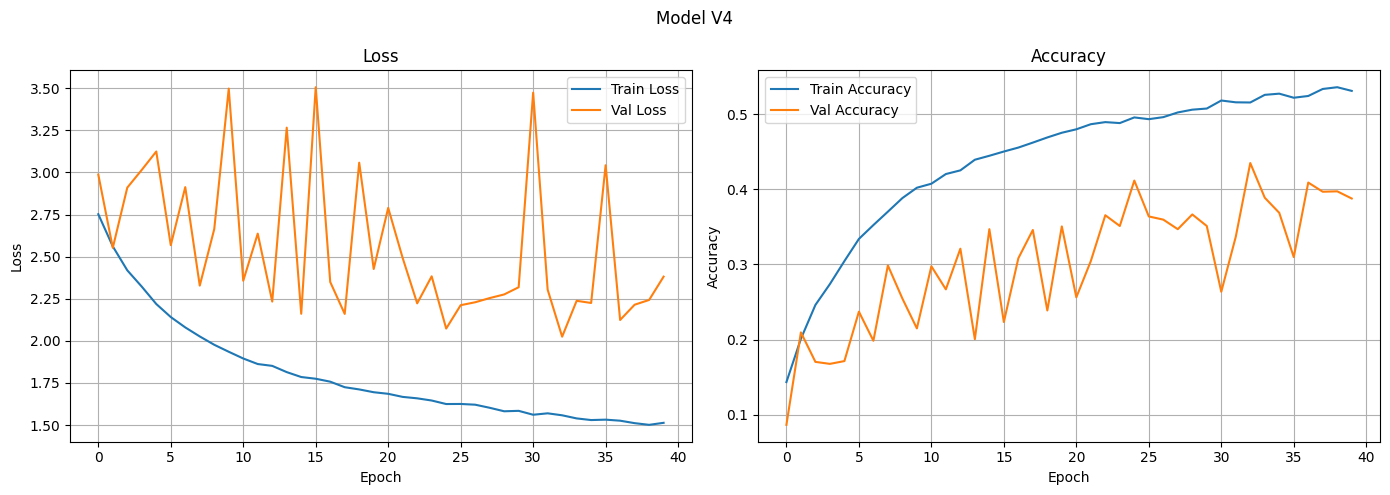

In [20]:
plot_history(food_cnn_stable_model_history, title='Model V4')

Epoch 1/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.1698 - loss: 2.7087 - val_accuracy: 0.1351 - val_loss: 3.1436
Epoch 2/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.2658 - loss: 2.3617 - val_accuracy: 0.2362 - val_loss: 2.4224
Epoch 3/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.3372 - loss: 2.1264 - val_accuracy: 0.2219 - val_loss: 2.5342
Epoch 4/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.3956 - loss: 1.9535 - val_accuracy: 0.2775 - val_loss: 2.3968
Epoch 5/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.4487 - loss: 1.7944 - val_accuracy: 0.1880 - val_loss: 2.8596
Epoch 6/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.4879 - loss: 1.6649 - val_accuracy: 0.3570 - val_loss: 2.1206
Epoch 7/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.5253 - loss: 1.5450 - val_accuracy: 0.3565 - val_loss: 2.1936
Epoch 8/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.5529 - loss: 1.4571 - 

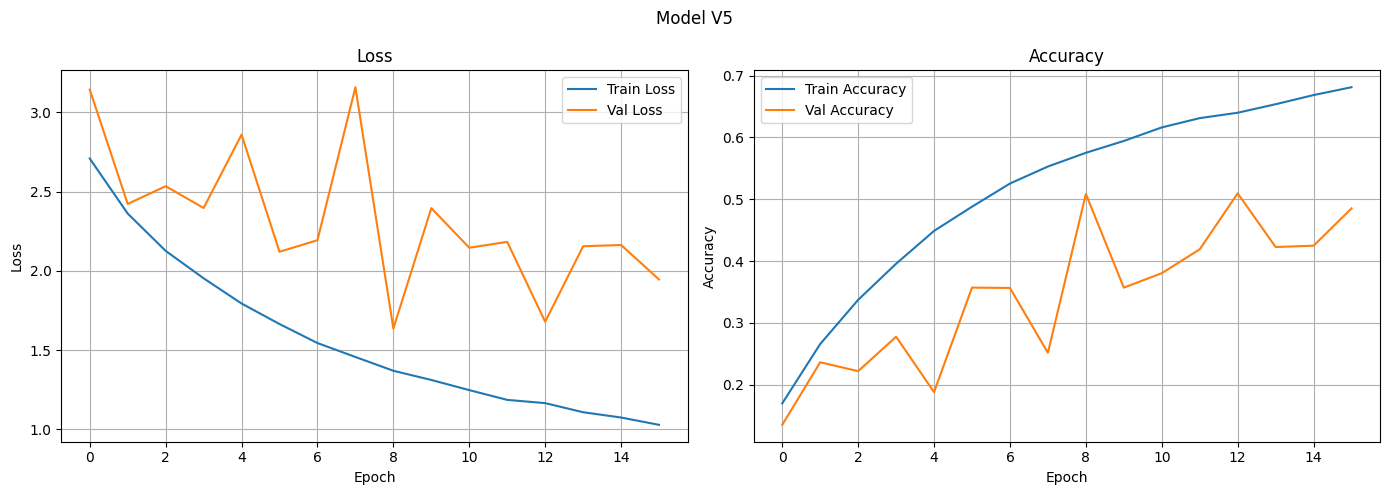

In [ ]:
def build_food_cnn_v5(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),


        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

build_food_cnn_v5_model = build_food_cnn_v5(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)

build_food_cnn_v5_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,        # increased — val is noisy so give it more room
    restore_best_weights=True
)

start_time = time.time()
EPOCHS=40

build_food_cnn_v5_model_history = build_food_cnn_v5_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[callback]
)

end_time = time.time()
total_time = end_time - start_time

model_performance_tracker["Model V5"] = {
    "Total Time (s)": round(total_time, 2),
    "Time/Epoch (s)": round(total_time / EPOCHS, 2),
    "Epochs": EPOCHS,
    "Final Train Acc": round(build_food_cnn_v5_model_history.history['accuracy'][-1], 4),
    "Final Val Acc": round(build_food_cnn_v5_model_history.history['val_accuracy'][-1], 4),
    "Final Train Loss": round(build_food_cnn_v5_model_history.history['loss'][-1], 4), 
    "Final Val Loss": round(build_food_cnn_v5_model_history.history['val_loss'][-1], 4)  
}

plot_history(build_food_cnn_v5_model_history, title='Model V5')


#### Model v6

Epoch 1/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.1637 - loss: 2.9144 - val_accuracy: 0.1960 - val_loss: 2.5890
Epoch 2/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.2398 - loss: 2.4577 - val_accuracy: 0.2595 - val_loss: 2.4139
Epoch 3/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.2931 - loss: 2.3002 - val_accuracy: 0.2638 - val_loss: 2.3517
Epoch 4/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.3415 - loss: 2.1365 - val_accuracy: 0.2977 - val_loss: 2.3107
Epoch 5/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.3856 - loss: 1.9912 - val_accuracy: 0.1716 - val_loss: 3.0837
Epoch 6/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.4347 - loss: 1.8539 - val_accuracy: 0.3019 - val_loss: 2.5843
Epoch 7/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.4720 - loss: 1.7373 - val_accuracy: 0.3681 - val_loss: 2.1718
Epoch 8/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.5053 - loss: 1.6345 - 

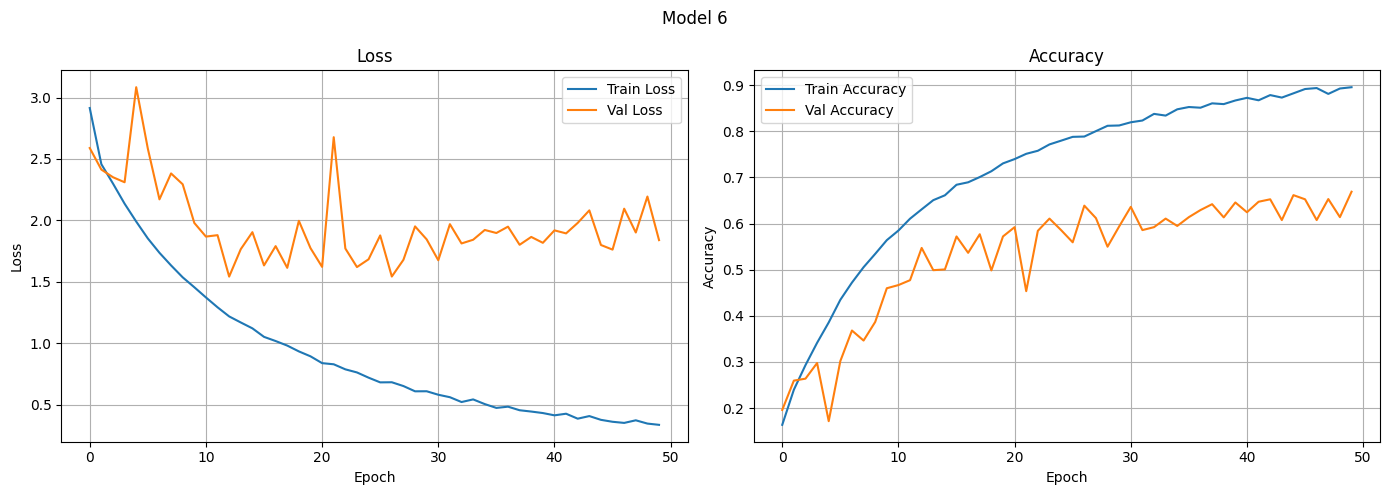

In [ ]:
def build_food_cnn_v6(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(512, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(1024, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),


        layers.GlobalAveragePooling2D(),
        layers.Dense(2048, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

build_food_cnn_v6_model = build_food_cnn_v6(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)

build_food_cnn_v6_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


start_time = time.time()
EPOCHS=50

build_food_cnn_v6_model_history = build_food_cnn_v6_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

end_time = time.time()
total_time = end_time - start_time

model_performance_tracker["Model V6"] = {
    "Total Time (s)": round(total_time, 2),
    "Time/Epoch (s)": round(total_time / EPOCHS, 2),
    "Epochs": EPOCHS,
    "Final Train Acc": round(build_food_cnn_v6_model_history.history['accuracy'][-1], 4),
    "Final Val Acc": round(build_food_cnn_v6_model_history.history['val_accuracy'][-1], 4),
    "Final Train Loss": round(build_food_cnn_v6_model_history.history['loss'][-1], 4), 
    "Final Val Loss": round(build_food_cnn_v6_model_history.history['val_loss'][-1], 4)  
}


plot_history(build_food_cnn_v6_model_history, title='Model 6')


#### Model v7

Epoch 1/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.1621 - loss: 2.7300 - val_accuracy: 0.1224 - val_loss: 2.8087
Epoch 2/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.2337 - loss: 2.4840 - val_accuracy: 0.1954 - val_loss: 2.6746
Epoch 3/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.2800 - loss: 2.3521 - val_accuracy: 0.2918 - val_loss: 2.3396
Epoch 4/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.3220 - loss: 2.2346 - val_accuracy: 0.3019 - val_loss: 2.2373
Epoch 5/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.3577 - loss: 2.1235 - val_accuracy: 0.3030 - val_loss: 2.2621
Epoch 6/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.3900 - loss: 2.0338 - val_accuracy: 0.2812 - val_loss: 2.3909
Epoch 7/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.4127 - loss: 1.9496 - val_accuracy: 0.3204 - val_loss: 2.2037
Epoch 8/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.4314 - loss: 1.8721 - 

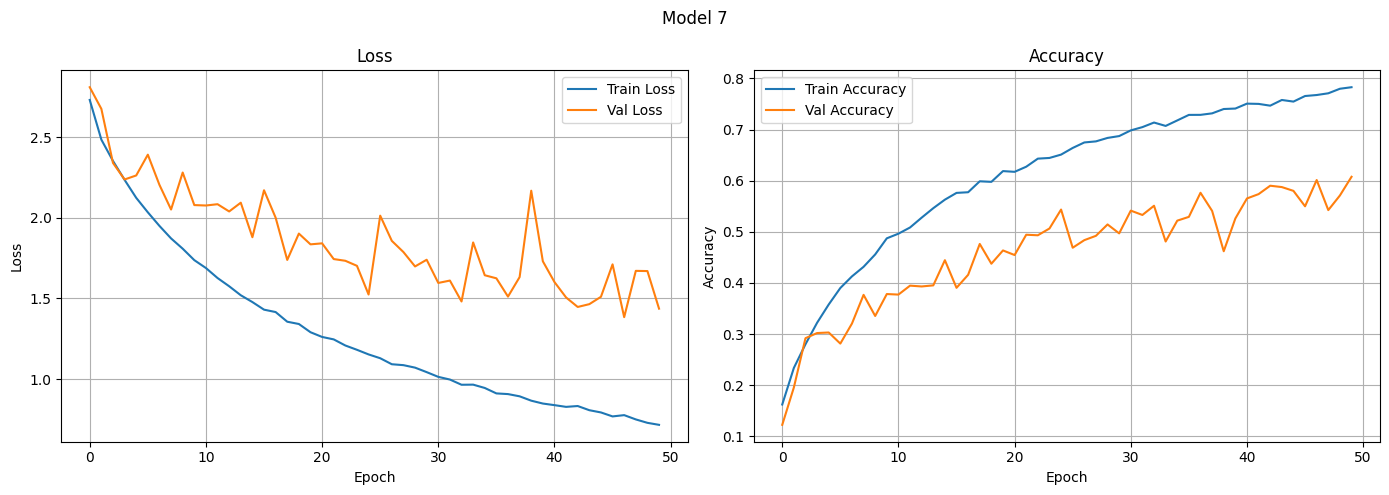

In [ ]:
def build_food_cnn_v7(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),

        layers.Conv2D(512, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.6),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

build_food_cnn_v7_model = build_food_cnn_v7(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)

build_food_cnn_v7_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


start_time = time.time()
EPOCHS=50

build_food_cnn_v7_model_history = build_food_cnn_v7_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

end_time = time.time()
total_time = end_time - start_time

model_performance_tracker["Model V7"] = {
    "Total Time (s)": round(total_time, 2),
    "Time/Epoch (s)": round(total_time / EPOCHS, 2),
    "Epochs": EPOCHS,
    "Final Train Acc": round(build_food_cnn_v7_model_history.history['accuracy'][-1], 4),
    "Final Val Acc": round(build_food_cnn_v7_model_history.history['val_accuracy'][-1], 4),
    "Final Train Loss": round(build_food_cnn_v7_model_history.history['loss'][-1], 4), 
    "Final Val Loss": round(build_food_cnn_v7_model_history.history['val_loss'][-1], 4)  
}


plot_history(build_food_cnn_v7_model_history, title='Model 7')

#### Model v8

Epoch 1/100
416/416 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.2029 - loss: 2.6662 - val_accuracy: 0.1155 - val_loss: 3.5293
Epoch 2/100
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.3014 - loss: 2.2559 - val_accuracy: 0.1970 - val_loss: 2.9388
Epoch 3/100
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.3532 - loss: 2.0887 - val_accuracy: 0.2341 - val_loss: 2.7719
Epoch 4/100
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.4062 - loss: 1.9328 - val_accuracy: 0.2908 - val_loss: 2.4380
Epoch 5/100
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.4415 - loss: 1.8080 - val_accuracy: 0.2071 - val_loss: 3.1322
Epoch 6/100
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.4690 - loss: 1.7061 - val_accuracy: 0.2034 - val_loss: 3.8284
Epoch 7/100
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.5008 - loss: 1.6050 - val_accuracy: 0.2039 - val_loss: 3.6762
Epoch 8/100
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.5293 - loss: 1

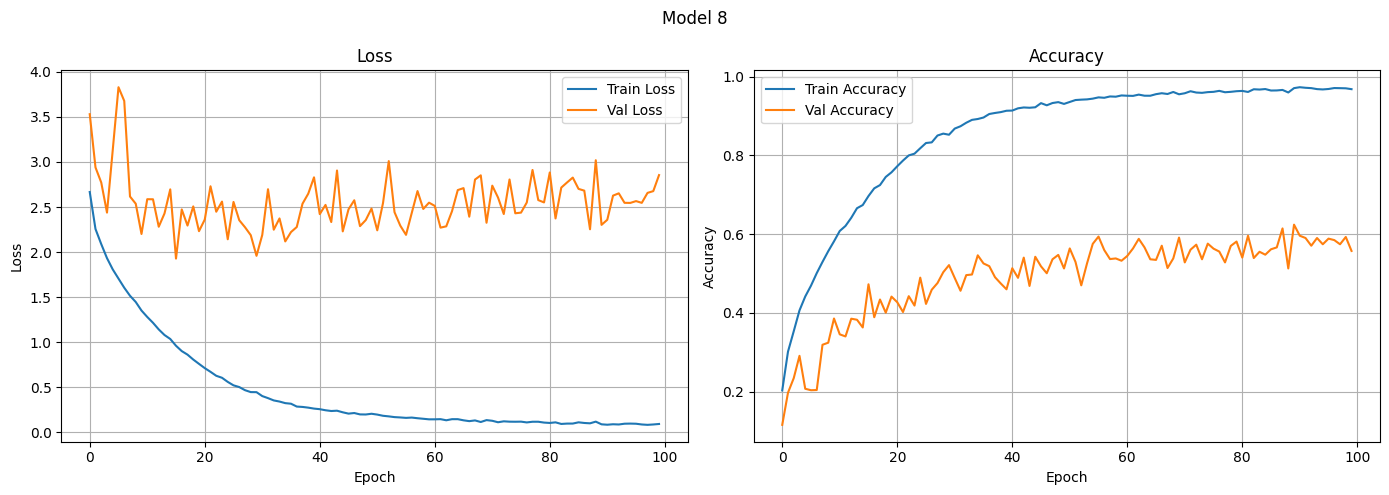

In [53]:
def build_food_cnn_v8(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(512, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(1024, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),


        layers.GlobalAveragePooling2D(),
        layers.Dense(2048, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

build_food_cnn_v8_model = build_food_cnn_v8(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)

build_food_cnn_v8_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


start_time = time.time()
EPOCHS=100

build_food_cnn_v8_model_history = build_food_cnn_v8_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

end_time = time.time()
total_time = end_time - start_time

model_performance_tracker["Model V8"] = {
    "Total Time (s)": round(total_time, 2),
    "Time/Epoch (s)": round(total_time / EPOCHS, 2),
    "Epochs": EPOCHS,
    "Final Train Acc": round(build_food_cnn_v8_model_history.history['accuracy'][-1], 4),
    "Final Val Acc": round(build_food_cnn_v8_model_history.history['val_accuracy'][-1], 4),
    "Final Train Loss": round(build_food_cnn_v8_model_history.history['loss'][-1], 4), 
    "Final Val Loss": round(build_food_cnn_v8_model_history.history['val_loss'][-1], 4)  
}


plot_history(build_food_cnn_v8_model_history, title='Model 8')

#### Grayscale (Model V6)

In [63]:
train_ds_gray = keras.utils.image_dataset_from_directory(
    "./food",
    color_mode='grayscale',
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="training"
)

print(train_ds_gray)

remaining_ds_gray = keras.utils.image_dataset_from_directory(
    "./food",
    color_mode='grayscale',
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="validation"
)

print(remaining_ds_gray)

remaining_batches_gray = tf.data.experimental.cardinality(remaining_ds_gray).numpy()
val_batches_gray = int(remaining_batches_gray * 0.33)
test_batches_gray = remaining_batches_gray - val_batches_gray

val_ds_gray = remaining_ds_gray.take(val_batches_gray)
test_ds_gray = remaining_ds_gray.skip(val_batches_gray)

Found 19000 files belonging to 19 classes.
Using 13300 files for training.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Found 19000 files belonging to 19 classes.
Using 5700 files for validation.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [67]:
def build_food_cnn_v6_grayscale(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(512, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(1024, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),


        layers.GlobalAveragePooling2D(),
        layers.Dense(2048, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

build_food_cnn_v6_grayscale_model = build_food_cnn_v6_grayscale(input_shape=(128, 128, 1), num_classes=NUM_CLASSES)

build_food_cnn_v6_grayscale_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


start_time = time.time()
EPOCHS=50

build_food_cnn_v6_grayscale_model_history = build_food_cnn_v6_grayscale_model.fit(
    train_ds_gray,
    validation_data=val_ds_gray,
    epochs=EPOCHS,
    class_weight=class_weights
)

end_time = time.time()
total_time = end_time - start_time

model_performance_tracker["Model V6 Grayscale"] = {
    "Total Time (s)": round(total_time, 2),
    "Time/Epoch (s)": round(total_time / EPOCHS, 2),
    "Epochs": EPOCHS,
    "Final Train Acc": round(build_food_cnn_v6_grayscale_model_history.history['accuracy'][-1], 4),
    "Final Val Acc": round(build_food_cnn_v6_grayscale_model_history.history['val_accuracy'][-1], 4),
    "Final Train Loss": round(build_food_cnn_v6_grayscale_model_history.history['loss'][-1], 4), 
    "Final Val Loss": round(build_food_cnn_v6_grayscale_model_history.history['val_loss'][-1], 4)  
}


plot_history(build_food_cnn_v6_grayscale_model_history, title='Model 6 Grayscale')


Epoch 1/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.1441 - loss: 2.9381 - val_accuracy: 0.1006 - val_loss: 3.3990
Epoch 2/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.2172 - loss: 2.5184 - val_accuracy: 0.1483 - val_loss: 2.8306
Epoch 3/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.2662 - loss: 2.3638 - val_accuracy: 0.2452 - val_loss: 2.4288
Epoch 4/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.3072 - loss: 2.2154 - val_accuracy: 0.1155 - val_loss: 3.4481
Epoch 5/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.3598 - loss: 2.0942 - val_accuracy: 0.1075 - val_loss: 4.4573
Epoch 6/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.3905 - loss: 1.9822 - val_accuracy: 0.3792 - val_loss: 2.1098
Epoch 7/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.4336 - loss: 1.8488 - val_accuracy: 0.3676 - val_loss: 2.0866
Epoch 8/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.4648 - loss: 1.7663 - 

KeyboardInterrupt: 

## Compare

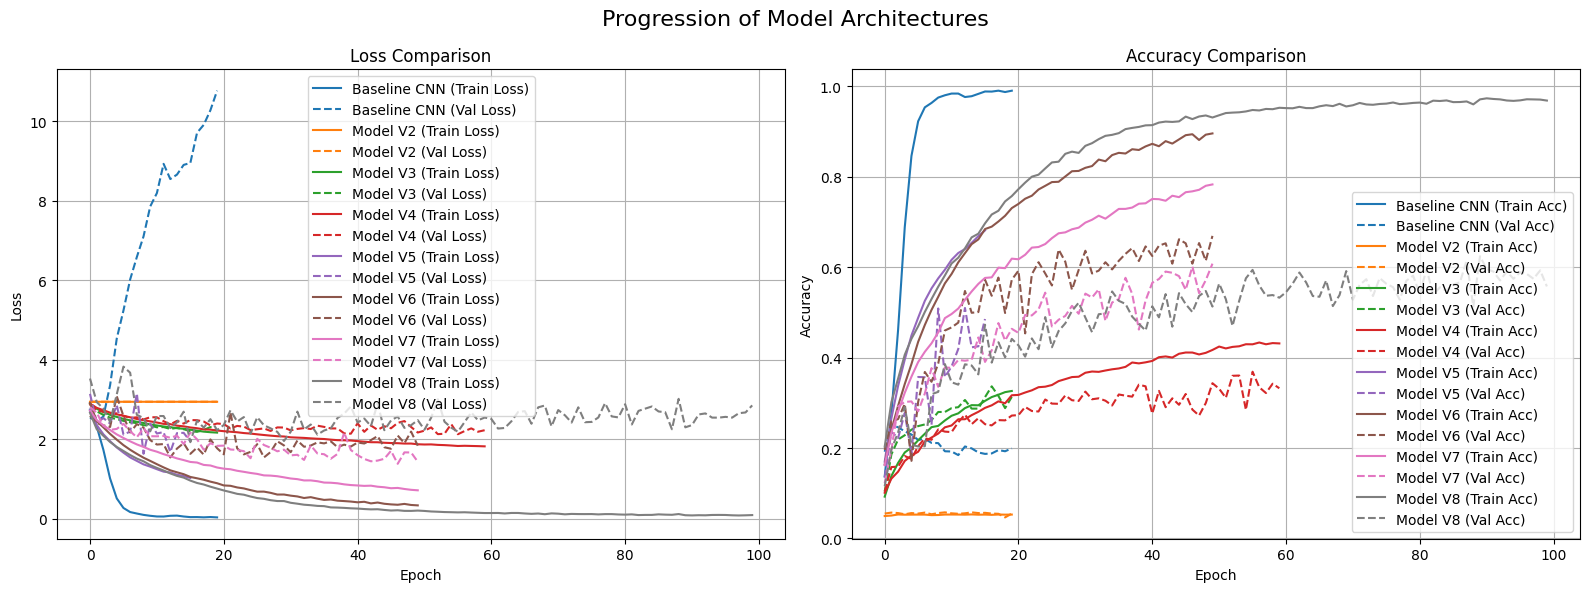

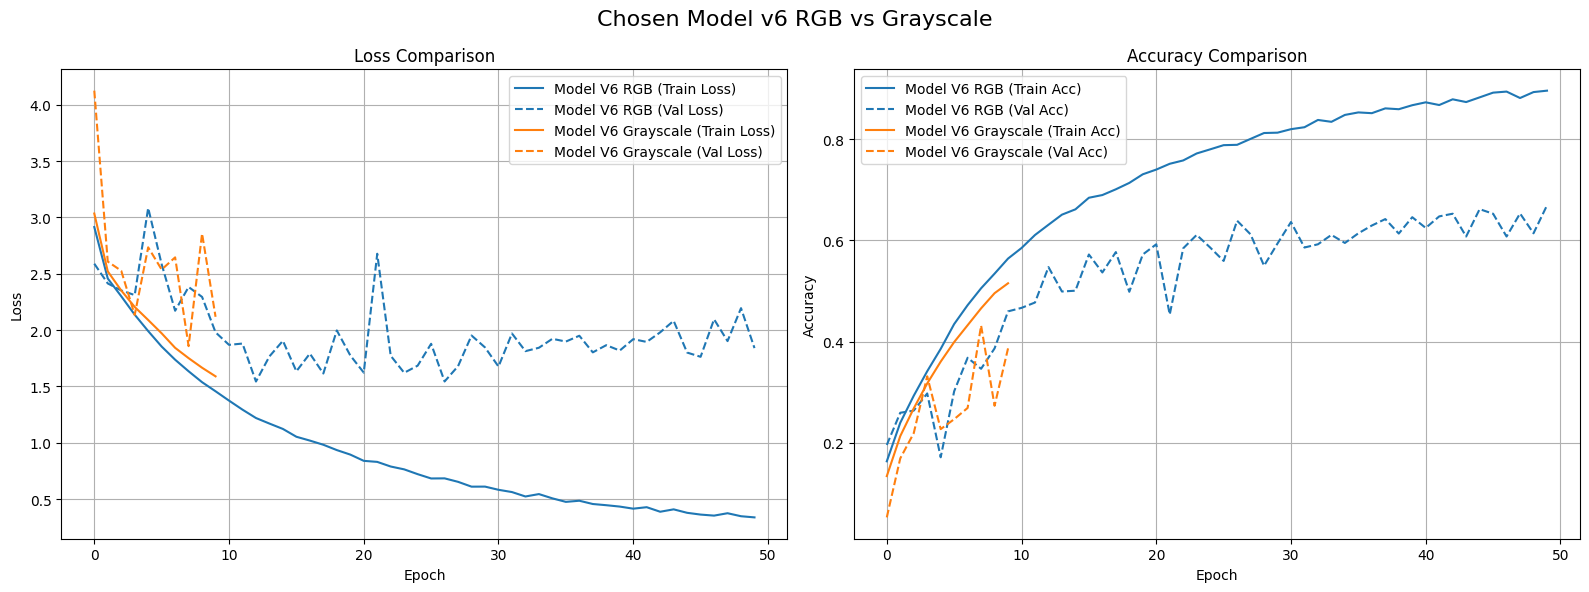

--- Final Model Performance Comparison ---


,Total Time (s),Time/Epoch (s),Final Train Acc,Final Val Acc,Final Train Loss,Final Val Loss,Epochs,Improvement (%)
Baseline CNN,1029.10,20.58,0.9899,0.1992,0.0360,10.7718,NaN,0.00
Model V2,1029.10,20.58,0.0529,0.0551,2.9446,2.9453,NaN,-14.41
Model V3,1029.10,20.58,0.3261,0.3130,2.1691,2.2151,NaN,11.38
Model V4,1029.10,20.58,0.4312,0.3321,1.8233,2.2290,NaN,13.29
Model V5,1029.10,20.58,0.6811,0.4852,1.0292,1.9460,NaN,28.60
Model V6,1029.10,20.58,0.8955,0.6690,0.3382,1.8402,NaN,46.98
Model V7,2033.53,20.34,0.7827,0.6075,0.7173,1.4370,NaN,40.83
Model V8,1926.95,19.27,0.9681,0.5572,0.0940,2.8540,100.0,35.80
Model V6 Grayscale,197.89,19.79,0.5152,0.3867,1.5897,2.1179,10.0,18.75


In [66]:
my_models = {
    'Baseline CNN': baseline_model_history,
    "Model V2": deeper_model_history,
    'Model V3': cnn_deeper_net_model_history,
    'Model V4': food_cnn_stable_model_history,
    'Model V5': build_food_cnn_v5_model_history,
    'Model V6': build_food_cnn_v6_model_history,
    'Model V7': build_food_cnn_v7_model_history,
    'Model V8': build_food_cnn_v8_model_history,
}

plot_model_comparison(my_models, title='Progression of Model Architectures')

my_models_grayscale = {
    'Model V6 RGB': build_food_cnn_v6_model_history,
    'Model V6 Grayscale': build_food_cnn_v6_grayscale_model_history,
}

plot_model_comparison(my_models_grayscale, title='Chosen Model v6 RGB vs Grayscale')

results_df = pd.DataFrame.from_dict(model_performance_tracker, orient='index')

# 2. Safety check: Only proceed if the DataFrame actually has data
if not results_df.empty:
    # 3. Calculate the improvement percentage relative to the first row (Baseline)
    # This creates a new column showing how much better each model is than the start
    baseline_acc = results_df.iloc[0]['Final Val Acc']
    results_df['Improvement (%)'] = (results_df['Final Val Acc'] - baseline_acc) * 100
    
    # 4. Round everything to 4 decimal places for a professional look
    results_df = results_df.round(4)
    
    # 5. Display the final table (Plain and clean, no .style needed)
    print("--- Final Model Performance Comparison ---")
    display(results_df)
else:
    print("Error: No data found in 'model_performance_tracker'.")
    print("Please ensure you've run the cells that save your model stats!")

# Transfer Learning

In [ ]:
IMAGE_SIZE_TL = (128, 128)

train_ds_tl = keras.utils.image_dataset_from_directory(
    "./food",
    image_size=IMAGE_SIZE_TL,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="training"
)

remaining_ds_tl = keras.utils.image_dataset_from_directory(
    "./food",
    image_size=IMAGE_SIZE_TL,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="validation"
)

remaining_batches = tf.data.experimental.cardinality(remaining_ds_tl).numpy()
val_batches = int(remaining_batches * 0.33)

val_ds_tl = remaining_ds_tl.take(val_batches)
test_ds_tl = remaining_ds_tl.skip(val_batches)


In [ ]:
import keras
from keras import layers
from keras.applications import MobileNetV2  # or VGG16, ResNet50

IMAGE_SIZE = (128, 128)  # match what the base model was trained on

# Step 1: Load the pre-trained base model
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,     # don't include the original ImageNet classifier
    weights='imagenet'     # use weights pre-trained on ImageNet
)

# Step 2: Freeze the base model — don't update its weights
base_model.trainable = False

print(f"Base model parameters: {base_model.count_params():,}")
print(f"Trainable: {sum([tf.size(v).numpy() for v in base_model.trainable_variables])}")

In [ ]:
# Step 3: Add preprocessing specific to the base model
# Each model has its own expected input range — use the built-in preprocessor
from keras.applications.mobilenet_v2 import preprocess_input  # use the right one for your model
# For VGG16: from keras.applications.vgg16 import preprocess_input
# For ResNet50: from keras.applications.resnet50 import preprocess_input

# Step 4: Build the full model
def build_transfer_model(base_model, num_classes):
    inputs = keras.Input(shape=(128, 128, 3))
    
    # Preprocessing: scale to the expected range for this model
    x = preprocess_input(inputs)   # MobileNetV2 expects [-1, 1], ResNet/VGG expect different ranges
    
    # Base model (frozen)
    x = base_model(x, training=False)  # training=False keeps BatchNorm in inference mode
    
    # Our new classifier head
    x = layers.GlobalAveragePooling2D()(x)   # convert spatial features to a vector
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    return model

model_tl = build_transfer_model(base_model, NUM_CLASSES)
model_tl.summary()

## Phase 1

In [ ]:
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # normal learning rate for the new head
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

import time
start = time.time()
history_tl = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weights
)
training_time_tl = time.time() - start

In [ ]:
plot_history(history_tl, title='Transfer Learning Phase 1')

## Phase 2 - Fine Tuning

In [ ]:
# Step 1: Unfreeze the top layers of the base model
base_model.trainable = True  # unfreeze everything

# Find out how many layers the base model has
print(f"Total layers in base model: {len(base_model.layers)}")

# Freeze all layers except the last N
fine_tune_from = len(base_model.layers) - 20  # unfreeze the top 20 layers

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False  # keep early layers frozen

# Check how many layers are now trainable
trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable layers: {trainable_count} / {len(base_model.layers)}")

In [ ]:
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 100x smaller than before
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 3: Train for at least 1 epoch (assignment requirement)
start = time.time()
history_ft = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,  # fine-tuning usually needs fewer epochs
    callbacks=[early_stopping],
    class_weight=class_weights
)
ft_time = time.time() - start

In [ ]:
plot_history(history_ft, title='Transfer Learning Phase 2')

In [ ]:
print("Phase 1 - Best val accuracy:", max(history_tl.history['val_accuracy']))
print("Phase 2 - Best val accuracy:", max(history_ft.history['val_accuracy']))

# Plot both histories
plot_history(history_tl, "Transfer Learning - Phase 1 (Frozen Base)")
plot_history(history_ft, "Transfer Learning - Phase 2 (Fine-Tuning)")

# Metrics and Evaluation

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_tl.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))  # class with highest probability
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute and plot the confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,         # show numbers in each cell
    fmt='d',            # format as integers
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4  # 4 decimal places
)
print(report)

In [ ]:
# Only do this for your FINAL chosen model
test_loss, test_accuracy = model_tl.evaluate(test_ds, verbose=1)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Then get per-class metrics
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model_tl.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

# Final Test

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image  # or use keras.utils.load_img

def predict_photo(image_path, model, class_names, image_size=(224, 224)):
    # Load and resize the image
    img = keras.utils.load_img(image_path, target_size=image_size)
    img_array = keras.utils.img_to_array(img)          # shape: (H, W, 3)
    img_array = np.expand_dims(img_array, axis=0)      # shape: (1, H, W, 3) — add batch dimension
    
    # Predict
    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])
    
    # Show the image and result
    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} ({confidence:.1%} confidence)")
    plt.axis('off')
    plt.show()
    
    # Show all class probabilities
    print("All predictions:")
    sorted_indices = np.argsort(predictions[0])[::-1]  # highest first
    for i in sorted_indices:
        print(f"  {class_names[i]}: {predictions[0][i]:.2%}")
    
    return predicted_class, confidence

# Test each of your 4 photos
photo_paths = [
    './test-photos/pizza.jpg'
]

for path in photo_paths:
    predicted, confidence = predict_photo(path, model, class_names)
    print(f"\n{path}: Predicted '{predicted}' with {confidence:.1%} confidence\n")